#### Import libraries

In [166]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

from unityvr.preproc import logproc
from unityvr.viz import viz

#### Load json file

In [336]:
dirName = '/Volumes/otopaliklab/Temporary_Storage/Aisha/Unity frames test data/10_03_2025_comparing builds/texture_yoffset_led'
fileName = "Log_2025-10-03_17-28-13_Yoffset_trial1.json"

# /Users/hamida/Desktop/Log_2025-09-25_19-15-54_testnew.json

dat = logproc.openUnityLog(dirName, fileName)

for i in range(20):
    print(dat[i]['frame'])
    print(json.dumps(dat[i], sort_keys=True, indent=4))

0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "sessionParameters": [
        "ficTracSpinWindow: 0",
        "ficTracSpinThreshold: 0",
        "timeoutSecs: 0",
        "backgroundCylinderTexture: C:\\Users\\hamida\\Desktop\\background-1505x606.png",
        "backgroundCylinderTexture2: "
    ],
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "heightPixels": 720,
    "refreshRateHz": 120,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "widthPixels": 480
}
1.0
{
    "ficTracBallRadius": 0.04500000178813934,
    "ficTracServerAddress": "127.0.0.1",
    "ficTracServerPort": 2000,
    "ficTracSmoothingCount": 1,
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
1.0
{
    "colliderType": "MeshCollider",
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "meshGameObjectPath": "Fly/FlyCamera3/FlyCamera3Screen",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 

## Difference in time from dat file itself

In [312]:
# group by frame
dat = pd.DataFrame(dat)
dat = dat.groupby("frame").mean().reset_index()

/var/folders/nz/36wz0cz90t34jt3ryz6_n08w0000gp/T/ipykernel_90889/578852151.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  dat = dat.groupby("frame").mean().reset_index()


In [313]:
dat

,frame,timeSecs,timeSecsAfterSplash,frameAfterSplash,refreshRateHz,widthPixels,heightPixels,ficTracServerPort,ficTracBallRadius,ficTracSmoothingCount,xpos,ypos,deltaTime,tracePD,imgFrameTrigger,ledTrigger,numberOfEntriesWritten
0,0.0,0.000000,0.000000,0.0,120.0,480.0,720.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,0.000000,0.000000,1.0,NaN,NaN,NaN,2000.0,0.045,1.0,0.000000,0.1,0.020000,NaN,NaN,NaN,NaN
2,2.0,0.020000,0.020000,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.020000,0.1,0.020000,0.429278,0.018815,-4.861971,NaN
3,3.0,0.028325,0.028325,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0.028325,0.1,0.008325,0.428926,0.018744,-3.637051,NaN
4,4.0,0.037476,0.037476,4.0,NaN,NaN,NaN,NaN,NaN,NaN,0.037476,0.1,0.009151,0.430358,0.018722,-9.719207,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75960,75960.0,634.340515,634.340515,75960.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008325,0.441752,0.021403,9.945544,NaN
75961,75961.0,634.348877,634.348877,75961.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008350,0.447102,0.021719,-9.388016,NaN
75962,75962.0,634.357239,634.357239,75962.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008333,0.450715,0.022288,-9.720417,NaN
75963,75963.0,634.365540,634.365540,75963.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008325,0.439118,0.021526,-9.721298,NaN


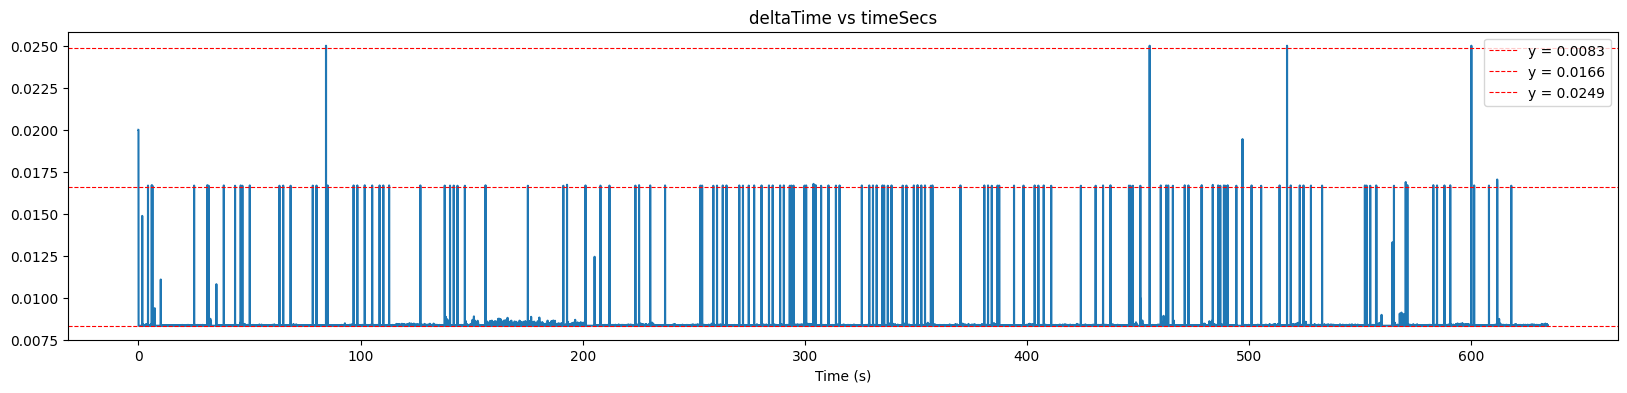

In [314]:
# timeSecs vs deltaTime from dat

plt.figure(figsize = (20, 4))
plt.plot(dat['timeSecs'], dat['deltaTime'])

# Add horizontal red lines at y = 0.0083 and y = 0.0166
plt.axhline(y=0.0083, color='red', linestyle='--', label='y = 0.0083', linewidth = 0.8)
plt.axhline(y=0.0166, color='red', linestyle='--', label='y = 0.0166', linewidth = 0.8)
plt.axhline(y=0.0249, color='red', linestyle='--', label='y = 0.0249', linewidth = 0.8)


plt.xlabel('Time (s)')
plt.legend()
plt.title('deltaTime vs timeSecs')
# plt.xlim([46, 48])
plt.show()

### difference between timeSecs per frame, calculate timeinterp

In [318]:
#difference between timeSecs per frame
dat['timeinterp'] = dat['timeSecs'].diff().fillna(0)

In [319]:
dat

,frame,timeSecs,timeSecsAfterSplash,frameAfterSplash,refreshRateHz,widthPixels,heightPixels,ficTracServerPort,ficTracBallRadius,ficTracSmoothingCount,xpos,ypos,deltaTime,tracePD,imgFrameTrigger,ledTrigger,numberOfEntriesWritten,timeinterp
0,0.0,0.000000,0.000000,0.0,120.0,480.0,720.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,1.0,0.000000,0.000000,1.0,NaN,NaN,NaN,2000.0,0.045,1.0,0.000000,0.1,0.020000,NaN,NaN,NaN,NaN,0.000000
2,2.0,0.020000,0.020000,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0.020000,0.1,0.020000,0.429278,0.018815,-4.861971,NaN,0.020000
3,3.0,0.028325,0.028325,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0.028325,0.1,0.008325,0.428926,0.018744,-3.637051,NaN,0.008325
4,4.0,0.037476,0.037476,4.0,NaN,NaN,NaN,NaN,NaN,NaN,0.037476,0.1,0.009151,0.430358,0.018722,-9.719207,NaN,0.009151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75960,75960.0,634.340515,634.340515,75960.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008325,0.441752,0.021403,9.945544,NaN,0.008301
75961,75961.0,634.348877,634.348877,75961.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008350,0.447102,0.021719,-9.388016,NaN,0.008362
75962,75962.0,634.357239,634.357239,75962.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008333,0.450715,0.022288,-9.720417,NaN,0.008362
75963,75963.0,634.365540,634.365540,75963.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008325,0.439118,0.021526,-9.721298,NaN,0.008301


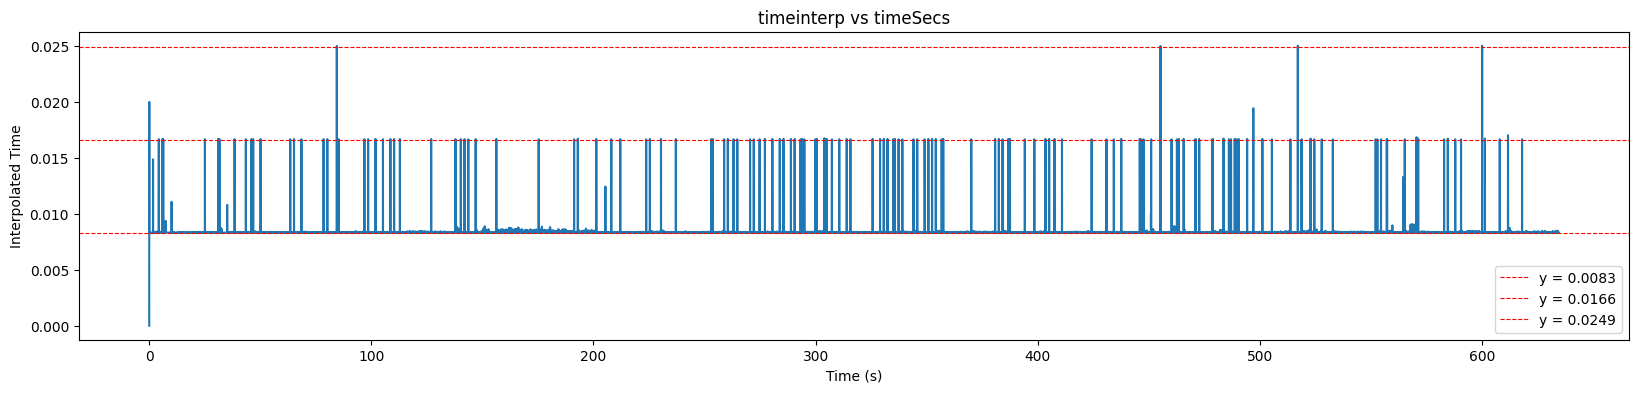

In [320]:
# timeSecs vs timeinterp computed

plt.figure(figsize=(20, 4))
plt.plot(dat['timeSecs'], dat['timeinterp'])

# Add horizontal red lines at y = 0.0083 and y = 0.0166
plt.axhline(y=0.0083, color='red', linestyle='--', label='y = 0.0083', linewidth = 0.8)
plt.axhline(y=0.0166, color='red', linestyle='--', label='y = 0.0166', linewidth = 0.8)
plt.axhline(y=0.0249, color='red', linestyle='--', label='y = 0.0249', linewidth = 0.8)


plt.xlabel('Time (s)')
plt.ylabel('Interpolated Time')
plt.legend()
plt.title('timeinterp vs timeSecs')
# plt.xlim([58.45, 58.55])
plt.show()

## Correct 'pdsig' as confirmed from wavesurfer data

In [211]:
dirName = '/Volumes/otopaliklab/Temporary_Storage/Aisha/Unity frames test data/10_03_2025_comparing builds/texture_yoffset_led'
fileName = "Log_2025-10-03_17-28-13_Yoffset_trial1.json"

# /Users/hamida/Desktop/Log_2025-09-25_19-15-54_testnew.json

dat = logproc.openUnityLog(dirName, fileName)

for i in range(5):
    print(dat[i]['frame'])
    print(json.dumps(dat[i], sort_keys=True, indent=4))

0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "sessionParameters": [
        "ficTracSpinWindow: 0",
        "ficTracSpinThreshold: 0",
        "timeoutSecs: 0",
        "backgroundCylinderTexture: C:\\Users\\hamida\\Desktop\\background-1505x606.png",
        "backgroundCylinderTexture2: "
    ],
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "heightPixels": 720,
    "refreshRateHz": 120,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "widthPixels": 480
}
1.0
{
    "ficTracBallRadius": 0.04500000178813934,
    "ficTracServerAddress": "127.0.0.1",
    "ficTracServerPort": 2000,
    "ficTracSmoothingCount": 1,
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
1.0
{
    "colliderType": "MeshCollider",
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "meshGameObjectPath": "Fly/FlyCamera3/FlyCamera3Screen",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 

In [212]:
posDf, ftDf, tsDf = logproc.timeseriesDfFromLog(dat)

correcting for Unity angle convention.
No fictrac signal was recorded.


In [285]:
tsDf

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp
0,1.0,0.00000,0.020000,NaN,NaN,NaN,NaN,0,1,1.000000,0.000000
1,2.0,0.02000,0.020000,0.428467,0.019470,-4.864334,0.428467,1,1,2.000000,0.020000
2,2.0,0.02000,0.020000,0.429756,0.018504,-4.862080,0.428467,0,1,2.008475,0.020071
3,2.0,0.02000,0.020000,0.426213,0.020436,-4.863046,0.429756,0,1,2.016949,0.020141
4,2.0,0.02000,0.020000,0.429756,0.018182,-4.861758,0.429756,0,1,2.025424,0.020212
...,...,...,...,...,...,...,...,...,...,...,...
2537720,75963.0,634.36554,0.008325,0.428789,0.022691,-9.723020,0.428789,0,1,75963.000000,634.365540
2537721,75963.0,634.36554,0.008325,0.428145,0.017538,-9.719477,0.428789,0,1,75963.000000,634.365540
2537722,75963.0,634.36554,0.008325,0.430078,0.024945,-9.720766,0.428789,0,1,75963.000000,634.365540
2537723,75963.0,634.36554,0.008325,0.428789,0.016894,-9.721088,0.428789,0,1,75963.000000,634.365540


In [286]:
tsDf['timenidaq'] = np.linspace(tsDf['time'].iloc[0], tsDf['time'].iloc[-1], len(tsDf))

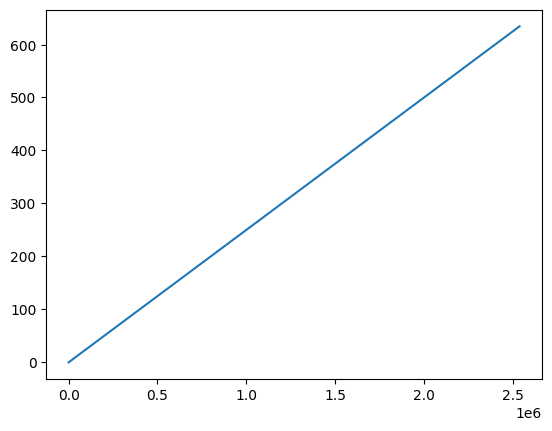

In [287]:
plt.plot(tsDf['timenidaq'])

In [ ]:
## Cross check wavesurfer arena frame clock start time
difference = 201 - 4.306317
print(difference)

(0.35, 0.5)

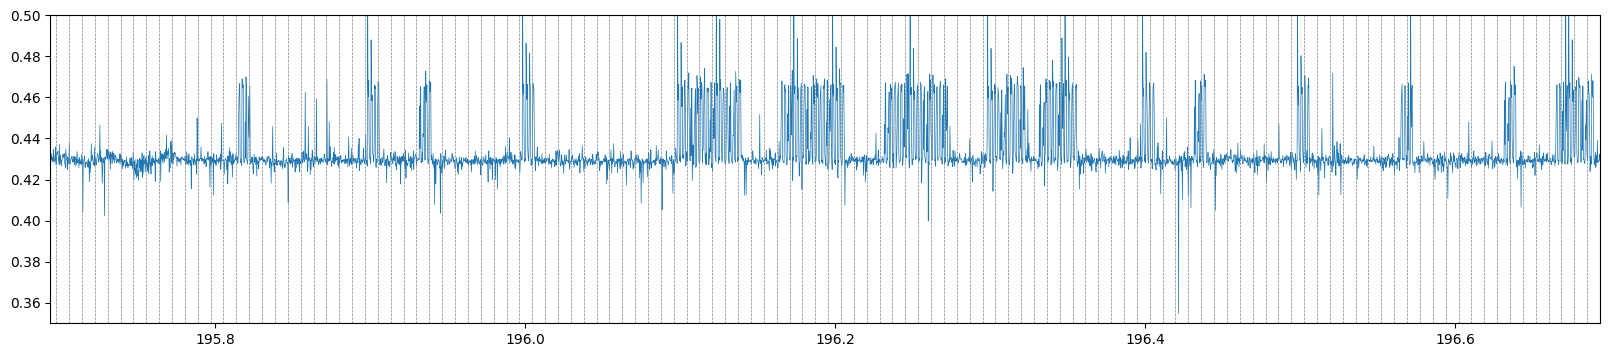

In [288]:
## Correct signal as compared to wavesurfer data
# Without grouping frames in tsdf, keep all data points 

plt.figure(figsize = (20, 4))

plt.plot(tsDf['timenidaq'], tsDf['pdsig'].values, linewidth=0.5), 

# Draw vertical lines at every 0.0083 seconds to see ideal duration of each frame
x_start = tsDf['timenidaq'].min()
x_end = tsDf['timenidaq'].max()
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)

plt.xlim([195.693683, 196.693683])
plt.ylim([0.35, 0.50])

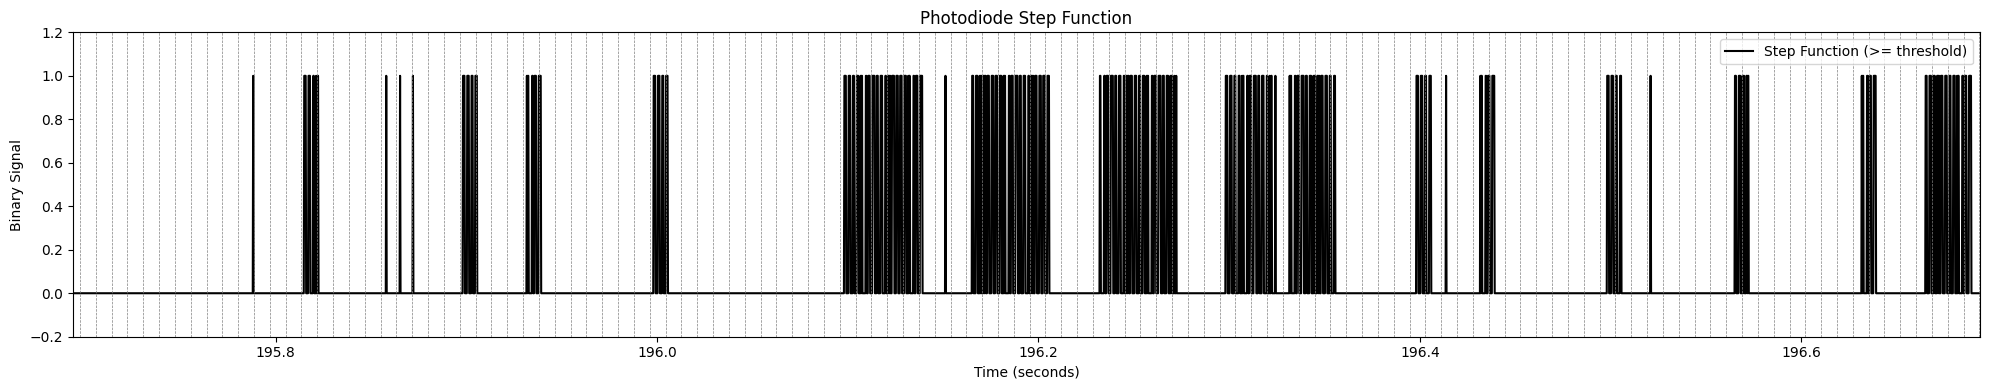

In [ ]:
# Create binary step function
threshold = 0.45
step_signal = (tsDf['pdsig'].values >= threshold).astype(int)

# Plot the step function
plt.figure(figsize=(20, 4))
plt.plot(tsDf['timenidaq'], step_signal, label="Step Function (>= threshold)", color='black')

plt.xlabel("Time (seconds)")
plt.ylabel("Binary Signal")
plt.title("Photodiode Step Function")
plt.grid(False)


# Get the min and max of x-axis (time)
x_start = tsDf['timenidaq'].min()
x_end = tsDf['timenidaq'].max()


# Create ticks every 0.0083 units
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)

plt.xlim([195.693683, 196.693683])
plt.ylim(-0.2, 1.2)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/nz/36wz0cz90t34jt3ryz6_n08w0000gp/T/ipykernel_90889/806107827.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


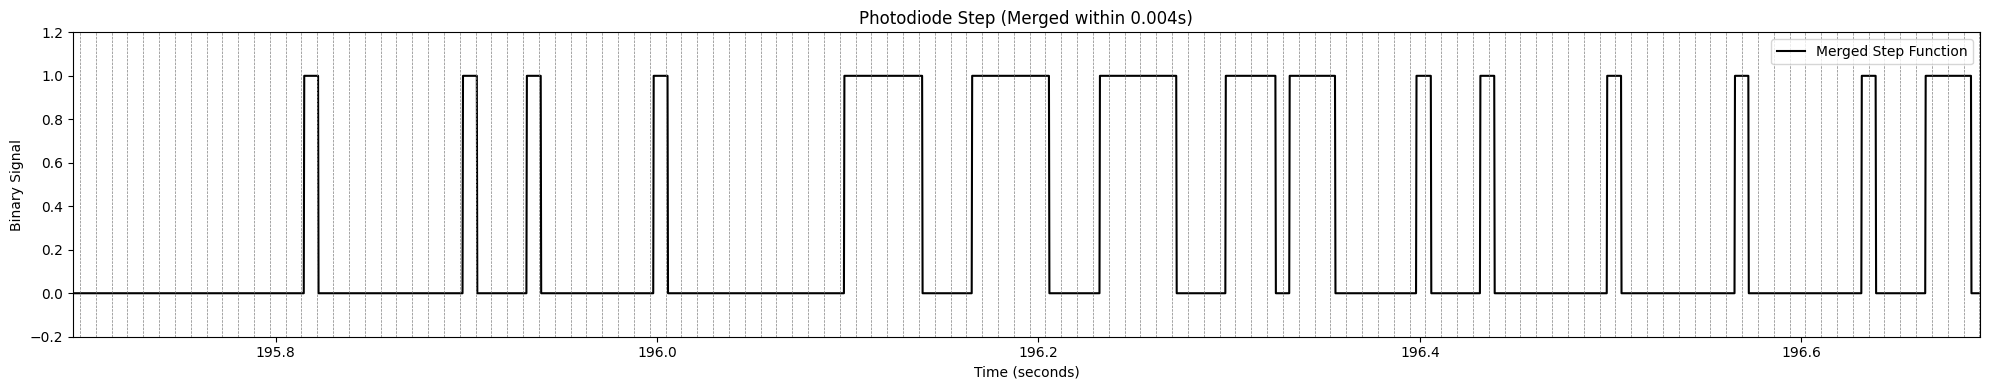

In [222]:
# Step 1: Get indices where signal changes
step_diff = np.diff(step_signal)
rising_edges = np.where(step_diff == 1)[0] + 1
falling_edges = np.where(step_diff == -1)[0] + 1

# Step 2: Ensure rising and falling pairs are matched correctly
if falling_edges[0] < rising_edges[0]:
    falling_edges = falling_edges[1:]
if len(rising_edges) > len(falling_edges):
    rising_edges = rising_edges[:-1]

# Step 3: Merge close 1-intervals (gap < 0.004 sec)
merged_intervals = []
min_gap = 0.004  # seconds

i = 0
while i < len(rising_edges):
    start_idx = rising_edges[i]
    end_idx = falling_edges[i]

    # Merge forward if next rise is close
    while (i + 1 < len(rising_edges)) and ((tsDf['timenidaq'][rising_edges[i + 1]] - tsDf['timenidaq'][falling_edges[i]]) < min_gap):
        end_idx = falling_edges[i + 1]
        i += 1

    merged_intervals.append((start_idx, end_idx))
    i += 1

# Step 4: Create compressed step signal
compressed_step = np.zeros_like(step_signal)

# for start, end in merged_intervals:
#     compressed_step[start:end] = 1

for start, end in merged_intervals:
    if tsDf['timenidaq'][end] - tsDf['timenidaq'][start] >= 0.006:
        compressed_step[start:end] = 1

# Step 5: Plot compressed step signal
plt.figure(figsize=(20, 4))
plt.plot(tsDf['timenidaq'], compressed_step, label="Merged Step Function", color='black')
plt.xlabel("Time (seconds)")
plt.ylabel("Binary Signal")
plt.title("Photodiode Step (Merged within 0.004s)")
plt.grid(False)

# Get the min and max of x-axis (time)
x_start = tsDf['timenidaq'].min()
x_end = tsDf['timenidaq'].max()


# Create ticks every 0.0083 units
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)


plt.xlim([195.693683, 196.693683])
plt.ylim(-0.2, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

In [225]:
# Step durations from compressed step function
durations = []

current_value = compressed_step[0]
start_idx = 0

for i in range(1, len(compressed_step)):
    if compressed_step[i] != current_value:
        end_idx = i
        start_time = tsDf['timenidaq'][start_idx]
        end_time = tsDf['timenidaq'][end_idx]
        duration = end_time - start_time

        durations.append({
            "start_time": start_time,
            "end_time": end_time,
            "duration": duration,
            "value": current_value  # 0 = black, 1 = white
        })

        start_idx = i
        current_value = compressed_step[i]

# Add the last segment
start_time = tsDf['timenidaq'][start_idx]
end_time = tsDf['timenidaq'].iloc[-1]
duration = end_time - start_time
durations.append({
    "start_time": start_time,
    "end_time": end_time,
    "duration": duration,
    "value": current_value
})

# Create DataFrame
df_durations = pd.DataFrame(durations)

In [226]:
df_durations

,start_time,end_time,duration,value
0,0.000000,0.110989,0.110989,0
1,0.110989,0.126237,0.015248,1
2,0.126237,0.152234,0.025997,0
3,0.152234,0.192980,0.040746,1
4,0.192980,0.218727,0.025747,0
...,...,...,...,...
63132,634.193807,634.294547,0.100740,0
63133,634.294547,634.310545,0.015998,1
63134,634.310545,634.319544,0.008999,0
63135,634.319544,634.361040,0.041496,1


In [227]:
# Define frame duration
frame_duration = 1 / 120  # ≈ 0.00833 s

# Add frame count and label
df_durations["n_frames"] = (df_durations["duration"] / frame_duration).round().astype(int)
df_durations["label"] = df_durations["value"].map({1: "white", 0: "black"})

In [228]:
df_durations

,start_time,end_time,duration,value,n_frames,label
0,0.000000,0.110989,0.110989,0,13,black
1,0.110989,0.126237,0.015248,1,2,white
2,0.126237,0.152234,0.025997,0,3,black
3,0.152234,0.192980,0.040746,1,5,white
4,0.192980,0.218727,0.025747,0,3,black
...,...,...,...,...,...,...
63132,634.193807,634.294547,0.100740,0,12,black
63133,634.294547,634.310545,0.015998,1,2,white
63134,634.310545,634.319544,0.008999,0,1,black
63135,634.319544,634.361040,0.041496,1,5,white


In [229]:
# Identify dropped frame events
drop_events = df_durations[df_durations["n_frames"] > 1].copy()

# Compute how many frames were dropped
drop_events["n_dropped"] = drop_events["n_frames"] - 1

# Compute midpoint time for plotting
drop_events["mid_time"] = (drop_events["start_time"] + drop_events["end_time"]) / 2

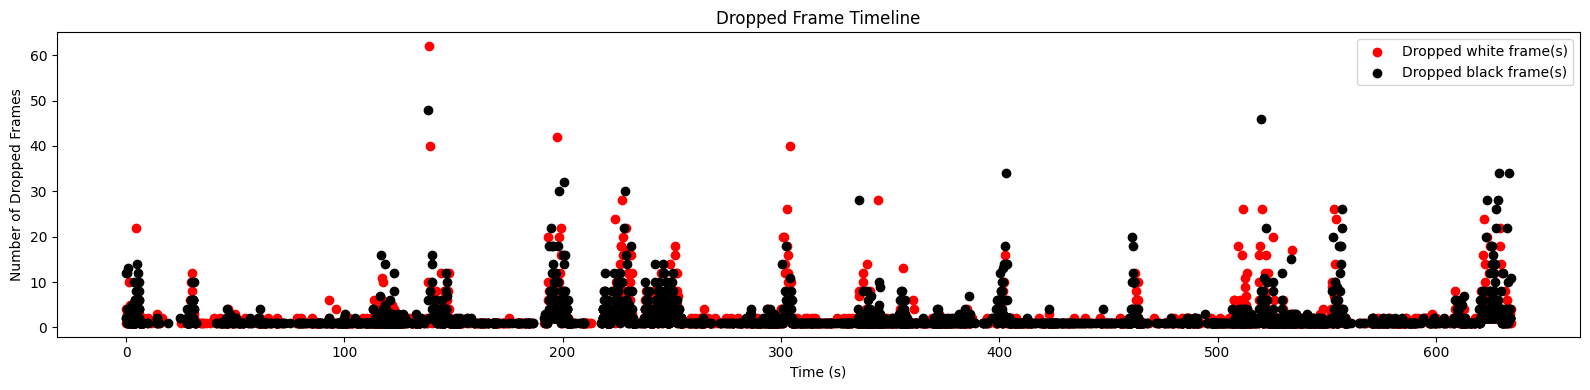

In [231]:
plt.figure(figsize=(16, 4))

# Plot by type
for drop_type, color in [("white", "red"), ("black", "black")]:
    subset = drop_events[drop_events["label"] == drop_type]
    plt.scatter(subset["mid_time"], subset["n_dropped"], color=color, label=f"Dropped {drop_type} frame(s)")

plt.xlabel("Time (s)")
plt.ylabel("Number of Dropped Frames")
plt.title("Dropped Frame Timeline")
plt.grid(False)
# plt.xlim(6, 77)
# plt.ylim(0, 70)
plt.legend()
plt.tight_layout()
plt.show()

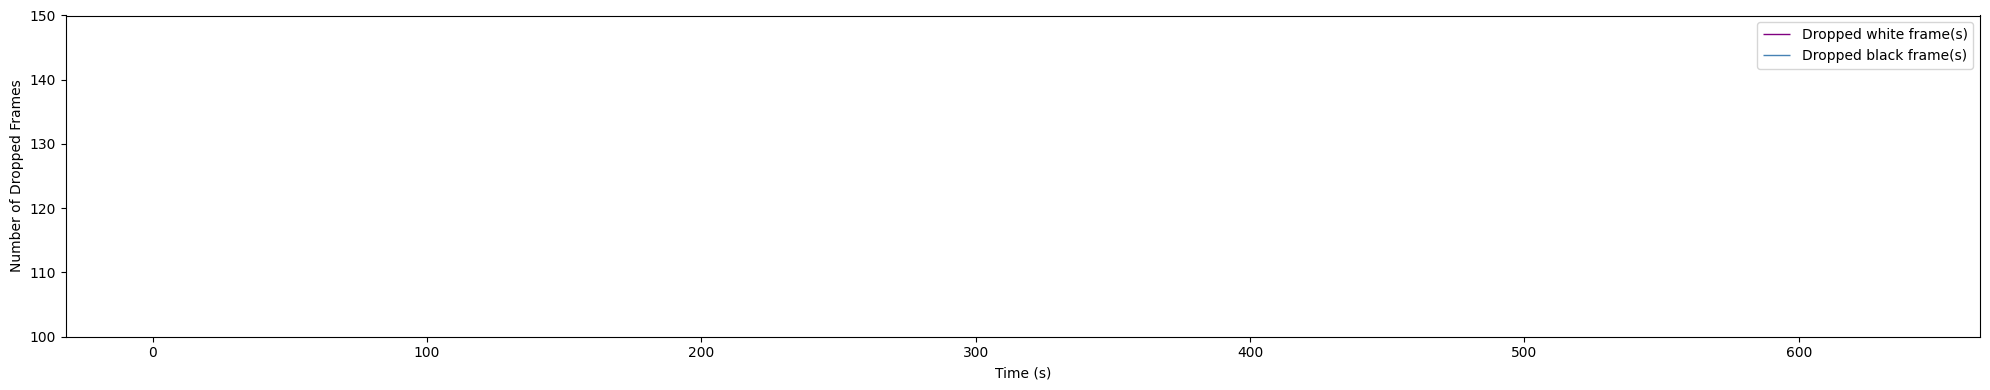

In [ ]:
plt.figure(figsize=(20, 4))

# Plot vertical lines per type
for drop_type, color in [("white", "purple"), ("black", "steelblue")]:
    subset = drop_events[drop_events["label"] == drop_type]
    plt.vlines(x=subset["mid_time"],
               ymin=0,
               ymax=subset["n_dropped"],
               color=color,
               label=f"Dropped {drop_type} frame(s)",
               linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Number of Dropped Frames")
# plt.title("Dropped Frame Timeline (One Line per Event)")
plt.grid(False)
# plt.xlim(352, 352.5)
plt.ylim(100, 150)

plt.legend()
plt.tight_layout()
plt.show()

### PLot time from tsdf/posdf again to get real time vector

In [ ]:
'where is the time vector going wrong in plotting delta time'
'somewhere when taking mean or grouping by frame, the time vector is off'
'take a look at the raw distributions'

In [381]:
posDf, ftDf, tsDf = logproc.timeseriesDfFromLog(dat)

correcting for Unity angle convention.
No fictrac signal was recorded.


In [324]:
posDf

,frame,time,dt,x,y,angle,dx_ft,dy_ft,dxattempt_ft,dyattempt_ft
0,1.0,0.000000,0.020000,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.020000,0.020000,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.028325,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.037476,0.009151,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
4,5.0,0.045801,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
75958,75959.0,634.332214,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
75959,75960.0,634.340515,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
75960,75961.0,634.348877,0.008350,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
75961,75962.0,634.357239,0.008333,0.0,-10.0,0.0,0.0,0.0,0.0,0.0


In [369]:
tsDf

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp,framestarttime
0,1.0,0.00000,0.020000,NaN,NaN,NaN,NaN,0,1,1.000000,0.000000,0.00000
1,2.0,0.02000,0.020000,0.428467,0.019470,-4.864334,0.428467,1,1,2.000000,0.020000,0.02000
2,2.0,0.02000,0.020000,0.429756,0.018504,-4.862080,0.428467,0,1,2.008475,0.020071,0.02000
3,2.0,0.02000,0.020000,0.426213,0.020436,-4.863046,0.429756,0,1,2.016949,0.020141,0.02000
4,2.0,0.02000,0.020000,0.429756,0.018182,-4.861758,0.429756,0,1,2.025424,0.020212,0.02000
...,...,...,...,...,...,...,...,...,...,...,...,...
2537720,75963.0,634.36554,0.008325,0.428789,0.022691,-9.723020,0.428789,0,1,75963.000000,634.365540,634.36554
2537721,75963.0,634.36554,0.008325,0.428145,0.017538,-9.719477,0.428789,0,1,75963.000000,634.365540,634.36554
2537722,75963.0,634.36554,0.008325,0.430078,0.024945,-9.720766,0.428789,0,1,75963.000000,634.365540,634.36554
2537723,75963.0,634.36554,0.008325,0.428789,0.016894,-9.721088,0.428789,0,1,75963.000000,634.365540,634.36554


In [370]:
# Step 1: Compute the first 'time' value for each frame
frame_start_times = tsDf.groupby('frame')['time'].first()

# Step 2: Map it back to the original dataframe
tsDf['framestarttime'] = tsDf['frame'].map(frame_start_times)

In [371]:
tsDf

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp,framestarttime
0,1.0,0.00000,0.020000,NaN,NaN,NaN,NaN,0,1,1.000000,0.000000,0.00000
1,2.0,0.02000,0.020000,0.428467,0.019470,-4.864334,0.428467,1,1,2.000000,0.020000,0.02000
2,2.0,0.02000,0.020000,0.429756,0.018504,-4.862080,0.428467,0,1,2.008475,0.020071,0.02000
3,2.0,0.02000,0.020000,0.426213,0.020436,-4.863046,0.429756,0,1,2.016949,0.020141,0.02000
4,2.0,0.02000,0.020000,0.429756,0.018182,-4.861758,0.429756,0,1,2.025424,0.020212,0.02000
...,...,...,...,...,...,...,...,...,...,...,...,...
2537720,75963.0,634.36554,0.008325,0.428789,0.022691,-9.723020,0.428789,0,1,75963.000000,634.365540,634.36554
2537721,75963.0,634.36554,0.008325,0.428145,0.017538,-9.719477,0.428789,0,1,75963.000000,634.365540,634.36554
2537722,75963.0,634.36554,0.008325,0.430078,0.024945,-9.720766,0.428789,0,1,75963.000000,634.365540,634.36554
2537723,75963.0,634.36554,0.008325,0.428789,0.016894,-9.721088,0.428789,0,1,75963.000000,634.365540,634.36554


In [379]:
frame_times = tsDf.groupby('frame')['time'].agg(['min', 'max']).reset_index()
frame_times['next_frame_min'] = frame_times['min'].shift(-1)
frame_times['duration'] = frame_times['next_frame_min'] - frame_times['max']

tsDf = tsDf.merge(frame_times[['frame', 'duration']], on='frame', how='left')

In [380]:
tsDf

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp,framestarttime,duration_x,duration_y
0,1.0,0.00000,0.020000,NaN,NaN,NaN,NaN,0,1,1.000000,0.000000,0.00000,0.020000,0.020000
1,2.0,0.02000,0.020000,0.428467,0.019470,-4.864334,0.428467,1,1,2.000000,0.020000,0.02000,0.008325,0.008325
2,2.0,0.02000,0.020000,0.429756,0.018504,-4.862080,0.428467,0,1,2.008475,0.020071,0.02000,0.008325,0.008325
3,2.0,0.02000,0.020000,0.426213,0.020436,-4.863046,0.429756,0,1,2.016949,0.020141,0.02000,0.008325,0.008325
4,2.0,0.02000,0.020000,0.429756,0.018182,-4.861758,0.429756,0,1,2.025424,0.020212,0.02000,0.008325,0.008325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2537720,75963.0,634.36554,0.008325,0.428789,0.022691,-9.723020,0.428789,0,1,75963.000000,634.365540,634.36554,NaN,NaN
2537721,75963.0,634.36554,0.008325,0.428145,0.017538,-9.719477,0.428789,0,1,75963.000000,634.365540,634.36554,NaN,NaN
2537722,75963.0,634.36554,0.008325,0.430078,0.024945,-9.720766,0.428789,0,1,75963.000000,634.365540,634.36554,NaN,NaN
2537723,75963.0,634.36554,0.008325,0.428789,0.016894,-9.721088,0.428789,0,1,75963.000000,634.365540,634.36554,NaN,NaN


In [372]:
tsDf_group = tsDf.groupby("frame").median().reset_index()

In [373]:
tsDf_group

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp,framestarttime
0,1.0,0.000000,0.020000,NaN,NaN,NaN,NaN,0.0,1.0,1.000000,0.000000,0.000000
1,2.0,0.020000,0.020000,0.429433,0.018826,-4.861758,0.429756,0.0,1.0,2.495763,0.024127,0.020000
2,3.0,0.028325,0.008325,0.429433,0.018826,-9.718511,0.429433,0.0,1.0,3.498084,0.032883,0.028325
3,4.0,0.037476,0.009151,0.430400,0.018504,-9.719155,0.430400,0.0,1.0,4.483871,0.041504,0.037476
4,5.0,0.045801,0.008325,0.429917,0.018343,-9.721088,0.429756,0.0,1.0,5.486111,0.049848,0.045801
...,...,...,...,...,...,...,...,...,...,...,...,...
75958,75959.0,634.332214,0.008325,0.434425,0.022369,9.946242,0.434264,0.0,1.0,75959.490741,634.336288,634.332214
75959,75960.0,634.340515,0.008325,0.429917,0.021725,9.944954,0.429917,0.0,1.0,75960.458333,634.344348,634.340515
75960,75961.0,634.348877,0.008350,0.438773,0.021081,-9.721410,0.438773,0.0,1.0,75961.491525,634.352987,634.348877
75961,75962.0,634.357239,0.008333,0.458418,0.021725,-9.719638,0.458418,0.0,1.0,75962.458333,634.361043,634.357239


In [374]:
tsDf_group['time_diff'] = tsDf_group['framestarttime'].diff()


In [375]:
tsDf_group

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp,framestarttime,time_diff
0,1.0,0.000000,0.020000,NaN,NaN,NaN,NaN,0.0,1.0,1.000000,0.000000,0.000000,NaN
1,2.0,0.020000,0.020000,0.429433,0.018826,-4.861758,0.429756,0.0,1.0,2.495763,0.024127,0.020000,0.020000
2,3.0,0.028325,0.008325,0.429433,0.018826,-9.718511,0.429433,0.0,1.0,3.498084,0.032883,0.028325,0.008325
3,4.0,0.037476,0.009151,0.430400,0.018504,-9.719155,0.430400,0.0,1.0,4.483871,0.041504,0.037476,0.009151
4,5.0,0.045801,0.008325,0.429917,0.018343,-9.721088,0.429756,0.0,1.0,5.486111,0.049848,0.045801,0.008325
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75958,75959.0,634.332214,0.008325,0.434425,0.022369,9.946242,0.434264,0.0,1.0,75959.490741,634.336288,634.332214,0.008301
75959,75960.0,634.340515,0.008325,0.429917,0.021725,9.944954,0.429917,0.0,1.0,75960.458333,634.344348,634.340515,0.008301
75960,75961.0,634.348877,0.008350,0.438773,0.021081,-9.721410,0.438773,0.0,1.0,75961.491525,634.352987,634.348877,0.008362
75961,75962.0,634.357239,0.008333,0.458418,0.021725,-9.719638,0.458418,0.0,1.0,75962.458333,634.361043,634.357239,0.008362


(0.0075, 0.009)

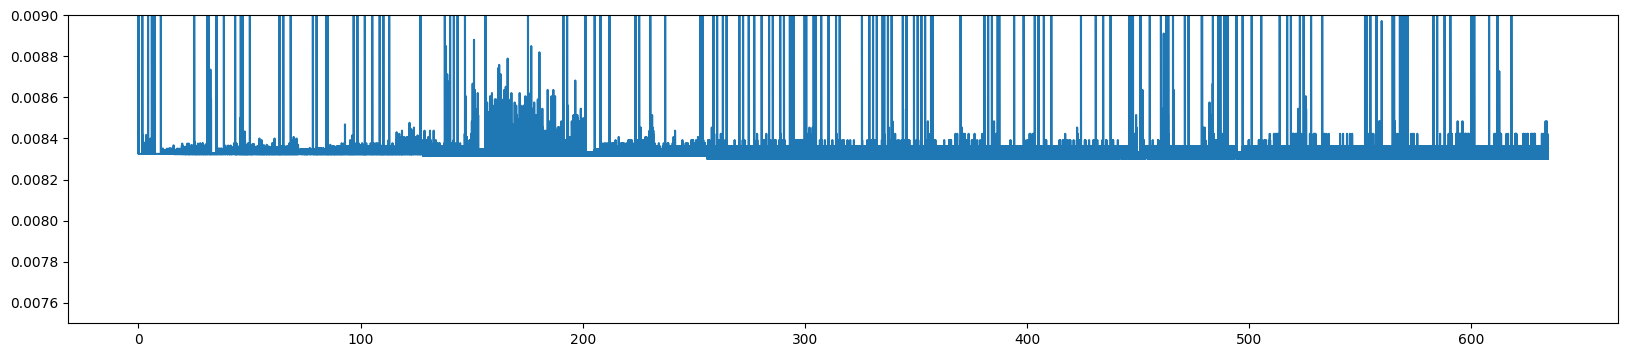

In [376]:
plt.figure(figsize = (20, 4))
plt.plot(tsDf_group['timeinterp'], tsDf_group['time_diff'])
plt.ylim(0.0075, 0.009)

### Compute pdsig from logproc, earlier code

In [ ]:
dirName = '/Volumes/otopaliklab/Temporary_Storage/Aisha/Unity frames test data/10_03_2025_comparing builds/texture_yoffset_led'
fileName = "Log_2025-10-03_17-28-13_Yoffset_trial1.json"

# /Users/hamida/Desktop/Log_2025-09-25_19-15-54_testnew.json

dat = logproc.openUnityLog(dirName, fileName)

for i in range(5):
    print(dat[i]['frame'])
    print(json.dumps(dat[i], sort_keys=True, indent=4))

0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "sessionParameters": [
        "ficTracSpinWindow: 0",
        "ficTracSpinThreshold: 0",
        "timeoutSecs: 0",
        "backgroundCylinderTexture: C:\\Users\\hamida\\Desktop\\background-1505x606.png",
        "backgroundCylinderTexture2: "
    ],
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "heightPixels": 720,
    "refreshRateHz": 120,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "widthPixels": 480
}
1.0
{
    "ficTracBallRadius": 0.04500000178813934,
    "ficTracServerAddress": "127.0.0.1",
    "ficTracServerPort": 2000,
    "ficTracSmoothingCount": 1,
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
1.0
{
    "colliderType": "MeshCollider",
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "meshGameObjectPath": "Fly/FlyCamera3/FlyCamera3Screen",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 

In [ ]:
posDf, ftDf, tsDf = logproc.timeseriesDfFromLog(dat)

correcting for Unity angle convention.
No analog input data was recorded.
No fictrac signal was recorded.


In [ ]:
posDf

,frame,time,dt,x,y,angle,dx_ft,dy_ft,dxattempt_ft,dyattempt_ft
0,1.0,0.000000,0.020000,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.020000,0.020000,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.028325,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.037476,0.009151,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
4,5.0,0.045801,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
75958,75959.0,634.332214,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
75959,75960.0,634.340515,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
75960,75961.0,634.348877,0.008350,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
75961,75962.0,634.357239,0.008333,0.0,-10.0,0.0,0.0,0.0,0.0,0.0


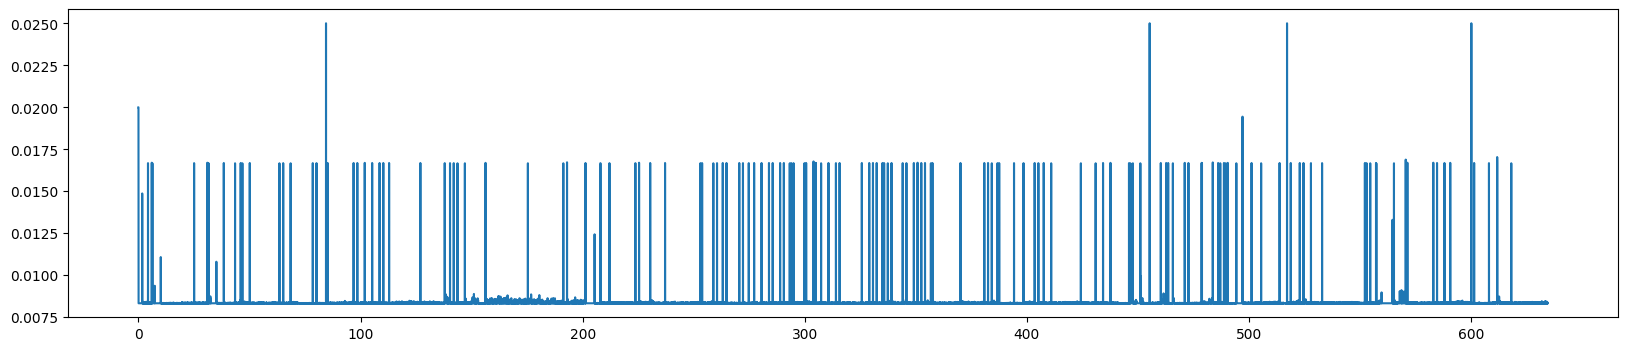

In [ ]:
plt.figure(figsize = (20, 4))
plt.plot(posDf['time'], posDf['dt'])

In [ ]:
posDf = posDf.groupby("frame").mean().reset_index()

In [ ]:
posDf

,frame,time,dt,x,y,angle,dx_ft,dy_ft,dxattempt_ft,dyattempt_ft
0,1.0,0.000000,0.020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.000000,0.020000,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.000000,0.020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.000000,0.020000,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
4,2.0,0.020000,0.020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
287203,71801.0,599.999817,0.008350,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
287204,71802.0,600.008179,0.008325,0.0,0.0,0.0,0.0,0.0,0.0,0.0
287205,71802.0,600.008179,0.008325,0.0,-10.0,0.0,0.0,0.0,0.0,0.0
287206,71802.0,600.008179,0.008325,0.0,0.0,0.0,0.0,0.0,0.0,0.0


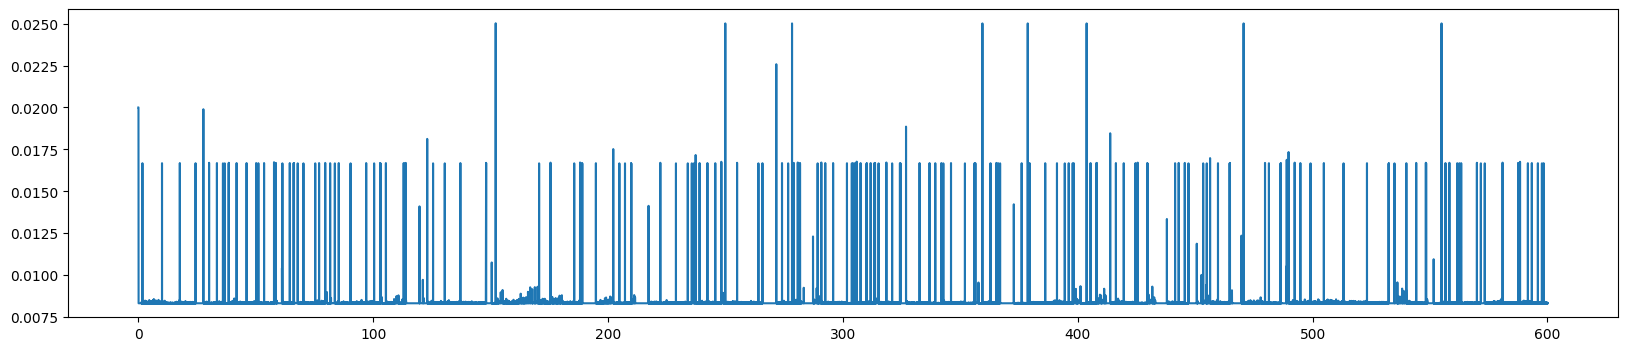

In [ ]:
plt.figure(figsize = (20, 4))
plt.plot(posDf['time'], posDf['dt'])

### timenidaq, computed as a equally spaced time interval from 1st and last time point, to avoid irregular sampling

In [ ]:
tsDf

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp
0,1.0,0.00000,0.020000,NaN,NaN,NaN,NaN,0,1,1.000000,0.000000
1,2.0,0.02000,0.020000,0.428467,0.019470,-4.864334,0.428467,1,1,2.000000,0.020000
2,2.0,0.02000,0.020000,0.429756,0.018504,-4.862080,0.428467,0,1,2.008475,0.020071
3,2.0,0.02000,0.020000,0.426213,0.020436,-4.863046,0.429756,0,1,2.016949,0.020141
4,2.0,0.02000,0.020000,0.429756,0.018182,-4.861758,0.429756,0,1,2.025424,0.020212
...,...,...,...,...,...,...,...,...,...,...,...
2537720,75963.0,634.36554,0.008325,0.428789,0.022691,-9.723020,0.428789,0,1,75963.000000,634.365540
2537721,75963.0,634.36554,0.008325,0.428145,0.017538,-9.719477,0.428789,0,1,75963.000000,634.365540
2537722,75963.0,634.36554,0.008325,0.430078,0.024945,-9.720766,0.428789,0,1,75963.000000,634.365540
2537723,75963.0,634.36554,0.008325,0.428789,0.016894,-9.721088,0.428789,0,1,75963.000000,634.365540


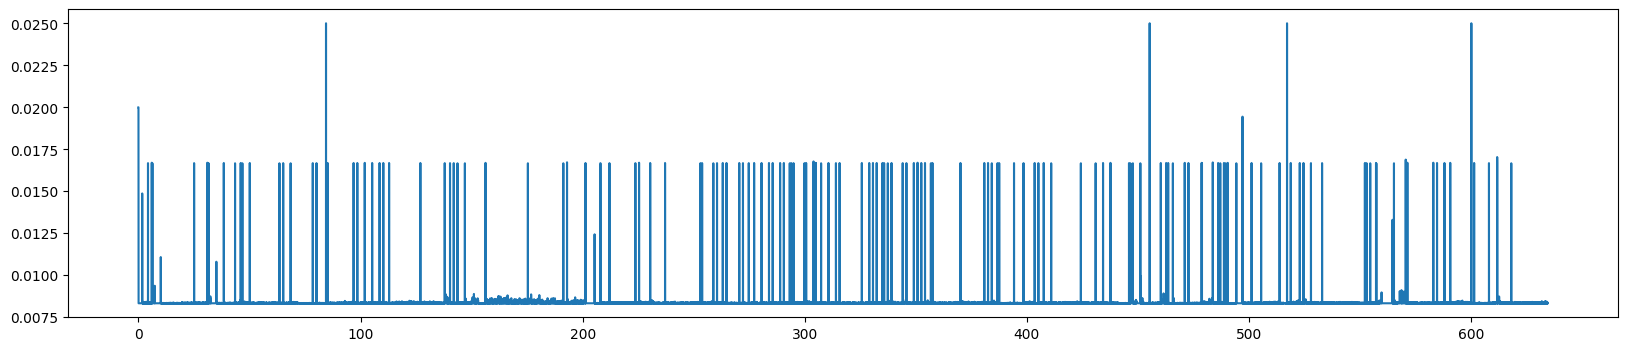

In [ ]:
plt.figure(figsize = (20, 4))
plt.plot(tsDf['time'], tsDf['dt'])

(200.0, 200.5)

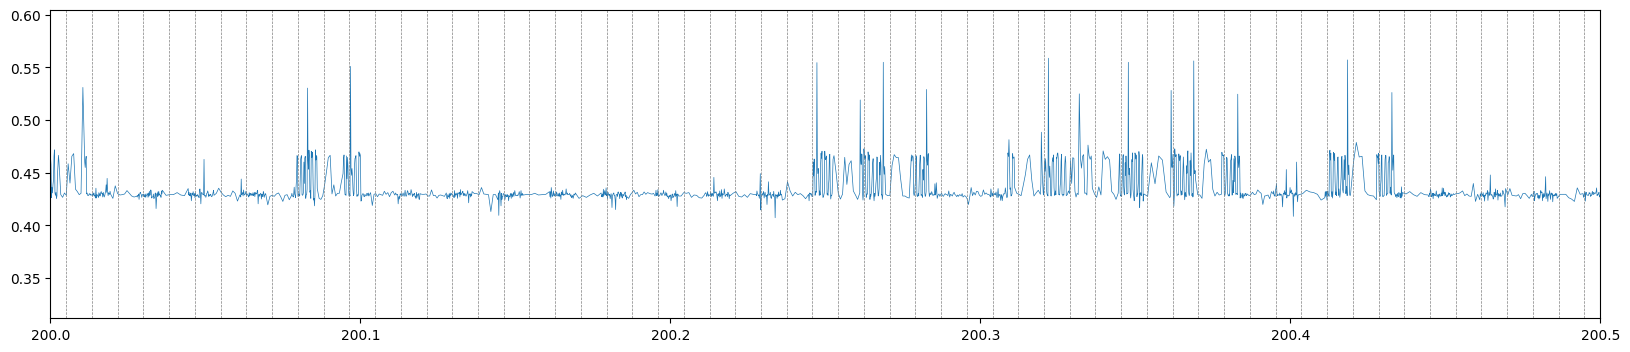

In [ ]:
plt.figure(figsize = (20, 4))
# plt.plot(tsDf['timenidaq'], tsDf['pdsig'].values, '.'), 
plt.plot(tsDf['timeinterp'], tsDf['pdsig'].values, linewidth=0.5), 

# Get the min and max of x-axis (time)
x_start = tsDf['timeinterp'].min()
x_end = tsDf['timeinterp'].max()


# Create ticks every 0.0083 units
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)
    
    
plt.xlim(200, 200.5)

In [ ]:
tsDf = tsDf.groupby("timeinterp").median().reset_index()

In [ ]:
tsDf

,frame,time,dt,pdsig,imgfsig,ledsig,pdFilt,framestart,counts,frameinterp,timeinterp,timenidaq
0,1.0,0.00000,0.020000,NaN,NaN,NaN,NaN,0,1,1.000000,0.000000,0.00000
1,2.0,0.02000,0.020000,0.428467,0.019470,-4.864334,0.428467,1,1,2.000000,0.020000,0.00025
2,2.0,0.02000,0.020000,0.429756,0.018504,-4.862080,0.428467,0,1,2.008475,0.020071,0.00050
3,2.0,0.02000,0.020000,0.426213,0.020436,-4.863046,0.429756,0,1,2.016949,0.020141,0.00075
4,2.0,0.02000,0.020000,0.429756,0.018182,-4.861758,0.429756,0,1,2.025424,0.020212,0.00100
...,...,...,...,...,...,...,...,...,...,...,...,...
2537720,75963.0,634.36554,0.008325,0.428789,0.022691,-9.723020,0.428789,0,1,75963.000000,634.365540,634.36454
2537721,75963.0,634.36554,0.008325,0.428145,0.017538,-9.719477,0.428789,0,1,75963.000000,634.365540,634.36479
2537722,75963.0,634.36554,0.008325,0.430078,0.024945,-9.720766,0.428789,0,1,75963.000000,634.365540,634.36504
2537723,75963.0,634.36554,0.008325,0.428789,0.016894,-9.721088,0.428789,0,1,75963.000000,634.365540,634.36529


(195.693683, 196.693683)

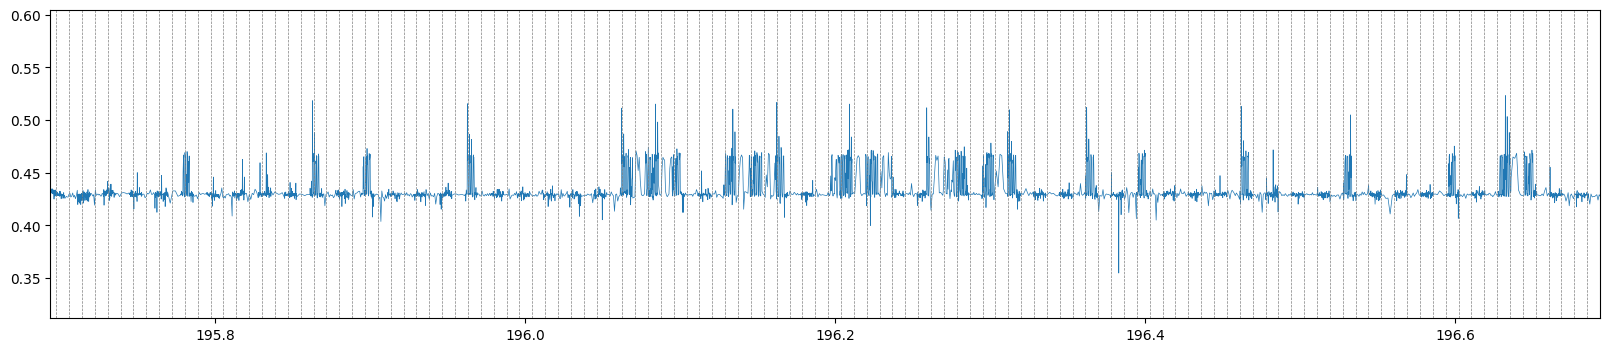

In [ ]:
plt.figure(figsize = (20, 4))
# plt.plot(tsDf['timenidaq'], tsDf['pdsig'].values, '.'), 
plt.plot(tsDf['timeinterp'], tsDf['pdsig'].values, linewidth=0.5), 

# Get the min and max of x-axis (time)
x_start = tsDf['timeinterp'].min()
x_end = tsDf['timeinterp'].max()


# Create ticks every 0.0083 units
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)
    
    
plt.xlim([195.693683, 196.693683])

In [ ]:
tsDf['timenidaq'] = np.linspace(tsDf['time'].iloc[0], tsDf['time'].iloc[-1], len(tsDf))

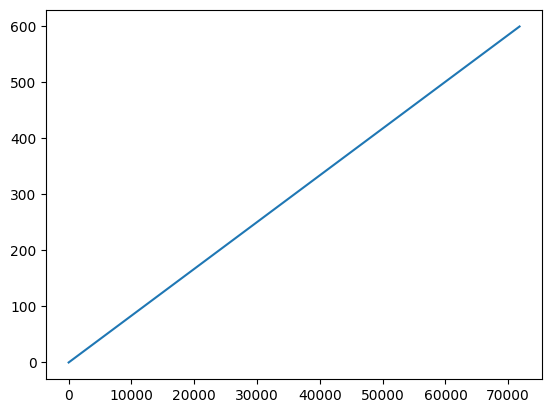

In [ ]:
plt.plot(tsDf['timenidaq'])

(28.0, 28.5)

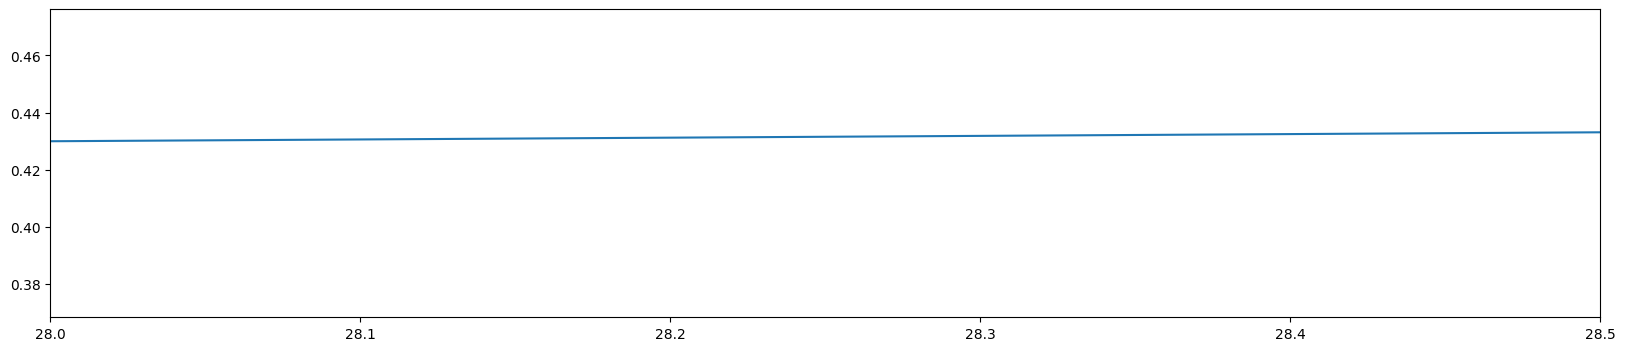

In [ ]:
plt.figure(figsize = (20, 4))
plt.plot(tsDf['pdsig'])
c

In [ ]:
difference = 201 - 4.306317
print(difference)


196.693683


(195.693683, 196.693683)

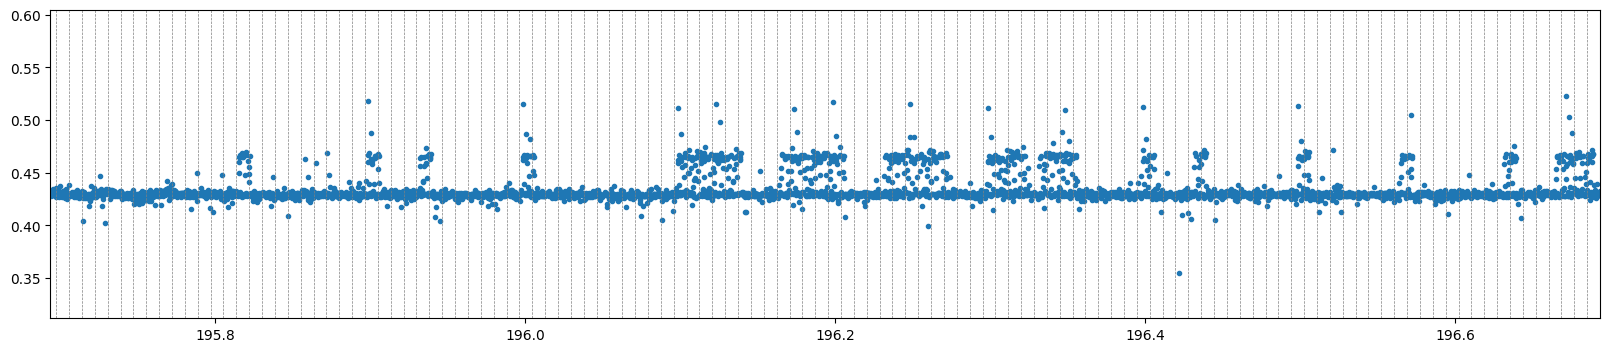

In [ ]:
## Correct signal as compared to wavesurfer data
# Without grouping frames in tsdf, keep all data points 

plt.figure(figsize = (20, 4))

plt.plot(tsDf['timenidaq'], tsDf['pdsig'].values, linewidth=0.5), 

# Draw vertical lines at every 0.0083 seconds to see ideal duration of each frame
x_start = tsDf['timenidaq'].min()
x_end = tsDf['timenidaq'].max()
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)

plt.xlim([195.693683, 196.693683])


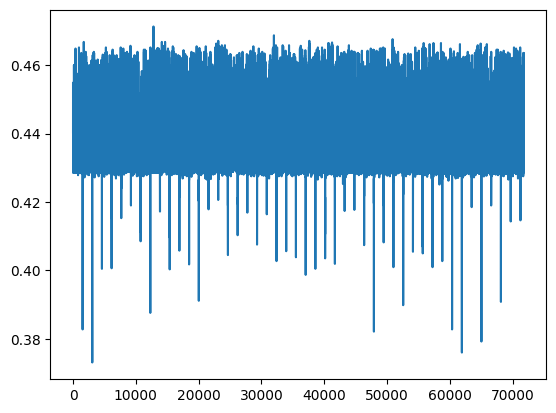

In [ ]:
plt.plot(tsDf['pdsig'])
plt.xlim([200, 60])

In [ ]:
tsDf['timenidaq'].values[500:505]

Text(0, 0.5, 'Time difference [s]')

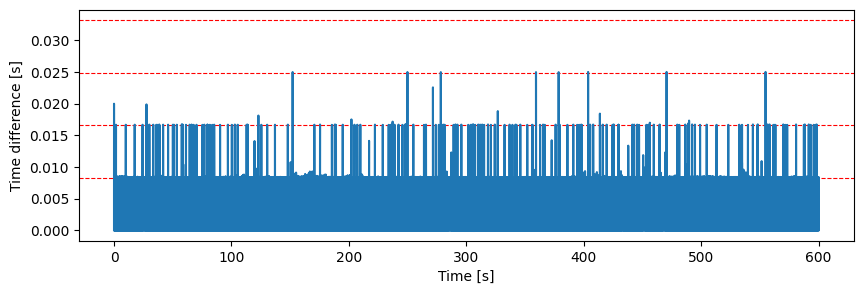

In [ ]:
plt.figure(figsize=(10, 3))

# Add horizontal red lines at y = 0.0083 and y = 0.0166
plt.axhline(y=0.0083, color='red', linestyle='--', label='y = 0.0083', linewidth = 0.8)
plt.axhline(y=0.0166, color='red', linestyle='--', label='y = 0.0166', linewidth = 0.8)
plt.axhline(y=0.0249, color='red', linestyle='--', label='y = 0.0249', linewidth = 0.8)
plt.axhline(y=0.0332, color='red', linestyle='--', label='y = 0.0332', linewidth = 0.8)

plt.plot(posDf['time'].iloc[1:], np.diff(posDf['time']))
# plt.axhline(1/120, color = 'r')
plt.xlabel('Time [s]')
plt.ylabel('Time difference [s]')
# plt.xlim([90.8, 91])